In [ ]:
import torch
from pathlib import Path
import sys

# 루트 경로 추가 (Model, dataset 로딩 위해)
root_dir = Path('/storage/personal/eungyeop/LLM/tabular/ProtoLLM')
sys.path.append(str(root_dir))

from models.TabularFLM_S import Model
from dataset.data_dataloaders import prepare_embedding_dataloaders
from utils.util import fix_seed
from ot.batch import solve_gromov_batch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4_entropictest3있음중요함!!/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-graddetach5_joint_lrdown/42/best_vanilla.pt"

# checkpoint load
ckpt = torch.load(ckpt_path, map_location=device)
args = ckpt['args']

# 모델 초기화
model = Model(
    args,
    args.input_dim,
    args.hidden_dim,
    args.output_dim,
    args.dropout_rate,
    args.llm_model,
    experiment_id="viz",
    mode="viz"
).to(device)

sd = ckpt['model_state_dict']
missing, unexpected = model.load_state_dict(sd, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()


In [ ]:
args2 = args
fix_seed(args2.random_seed)

# source_data가 리스트일 경우 여러 개
sources = args2.source_data if isinstance(args2.source_data, (list, tuple)) else [args2.source_data]

loaders = {}
for src in sources:
    print(f"Loading dataloader for source: {src}")
    res = prepare_embedding_dataloaders(args2, src)
    tr, va, te = res['loaders']
    
    from torch.utils.data import ConcatDataset, DataLoader
    ds = ConcatDataset([tr.dataset, va.dataset, te.dataset])
    
    loaders[src] = DataLoader(ds, batch_size=32, shuffle=False)


In [ ]:
import torch.nn.functional as F

@torch.no_grad()
def extract_basis_attention_and_embedding(model, batch):
    batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}

    # desc/name/value gather
    desc_embeddings, name_embeddings, value_embeddings = [], [], []
    if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
        desc_embeddings.append(batch['cat_desc_embeddings'])
        name_embeddings.append(batch['cat_name_embeddings'])
        value_embeddings.append(batch['cat_value_embeddings'])
    if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
        desc_embeddings.append(batch['num_desc_embeddings'])
        name_embeddings.append(batch['num_name_embeddings'])
        value_embeddings.append(batch['num_prompt_embeddings'])

    desc = torch.cat(desc_embeddings, dim=1)
    name = torch.cat(name_embeddings, dim=1)
    value = torch.cat(value_embeddings, dim=1)

    # CLS + value token concat
    x_basis = torch.cat([model.basis_cls.expand(value.size(0), 1, model.input_dim), value], dim=1)

    attentions = []

    # each BasisGAT layer
    for l in range(model.num_basis_layers):
        norm_x = model.basis_layer_norms[l](x_basis)
        basis_outputs, att = model.basis_layers[l](name, norm_x)
        
        # attention shape: [B, H, T, T]
        attentions.append(att[0].detach().cpu().numpy())
        
        x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

    embeddings = x_basis[0].detach().cpu().numpy()  # CLS+tokens, shape [T, D]
    return attentions, embeddings


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
def plot_attention_heatmap(att, feature_names, title):
    H, T, _ = att.shape
    # ---- Bigger, readable figure ----
    figsize_x = max(8, T * 0.8)  # at least width 8
    figsize_y = max(4, H * 3)    # at least height 4

    plt.figure(figsize=(figsize_x, figsize_y))

    for h in range(H):
        plt.subplot(1, H, h+1)
        plt.imshow(att[h], cmap='viridis')

        plt.xticks(range(T), feature_names, rotation=90, fontsize=10)
        plt.yticks(range(T), feature_names, fontsize=10)

        plt.title(f"{title} - Head {h}", fontsize=14)
        plt.colorbar()

    plt.tight_layout()
    plt.show()
from sklearn.manifold import TSNE

def plot_embedding_tsne(emb):
    # emb: [T, D]
    tsne = TSNE(n_components=2, perplexity=10, learning_rate=100)
    xy = tsne.fit_transform(emb)

    plt.figure(figsize=(6, 6))
    plt.scatter(xy[:, 0], xy[:, 1])
    for i in range(xy.shape[0]):
        plt.text(xy[i,0], xy[i,1], str(i), fontsize=8)
    plt.title("t-SNE of embeddings (CLS + features)")
    plt.show()

# ---- viz utilities ----
def set_attention_save_dir( experiment_id, mode):
    base_viz_dir = f"/storage/personal/eungyeop/experiments/visualization/{args.llm_model}/{args.source_data}/{mode}/{experiment_id}"
    attention_save_dir = os.path.join(base_viz_dir, 'attention_maps')
    os.makedirs(attention_save_dir, exist_ok=True)

def extract_feature_names( batch):
    names = []
    if 'cat_desc_texts' in batch:
        for t in batch['cat_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    if 'num_desc_texts' in batch:
        for t in batch['num_desc_texts']:
            names.append(str(t[0] if isinstance(t, tuple) else t).split(",")[0].split("'")[0])
    uniq = []
    seen = set()
    for n in names:
        if n not in seen:
            seen.add(n); uniq.append(n)
    return uniq

def save_attention_maps_to_file( attention_weights, batch, labels=None, sample_ids=None):
    if attention_save_dir is None:
        return
    node_names = ["CLS"] + extract_feature_names(batch)
    for layer_idx, layer_attention in enumerate(attention_weights):
        B = layer_attention.shape[0]
        for b in range(B):
            att = layer_attention[b].mean(dim=0).detach().cpu().numpy()
            sid = sample_ids[b] if sample_ids is not None else attention_counter
            lab = labels[b].item() if labels is not None else "unknown"
            np.savez(os.path.join(attention_save_dir, f"layer_{layer_idx}_sample_{sid}_label_{lab}.npz"),
                        attention_map=att, feature_names=np.array(node_names),
                        layer_idx=layer_idx, sample_id=sid, label=lab)
            attention_counter += 1

import numpy as np

def summarize_embedding_stats(emb, feature_names):
    """
    emb: numpy array [T, D]
    feature_names: list of T names ("CLS" + variable names)
    """
    T, D = emb.shape
    
    print("=== Embedding statistics per token (CLS + features) ===")
    stats = {}
    
    for i in range(T):
        vec = emb[i]
        mean = vec.mean()
        std = vec.std()
        
        stats[feature_names[i]] = {
            'mean': float(mean),
            'std': float(std)
        }
        print(f"{feature_names[i]:>15}  | mean={mean:.4f} | std={std:.4f}")
    
    # 전체 embedding 분포 요약
    print("\n=== Global embedding statistics ===")
    print(f"global mean: {emb.mean():.4f}")
    print(f"global std : {emb.std():.4f}")
    
    return stats

import matplotlib.pyplot as plt
import numpy as np

def plot_attention_with_inverse(
    att,
    feature_names,
    title="Attention",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0,
):
    H, T, _ = att.shape

    figsize_x = max(10, T * 0.7) * figsize_scale
    figsize_y = max(5, H * 3) * figsize_scale

    fig, axes = plt.subplots(H, 2, figsize=(figsize_x, figsize_y))
    if H == 1:
        axes = np.expand_dims(axes, 0)

    cmap = "viridis"

    for h in range(H):
        # ---- LEFT: Attention ----
        left_vmin = att[h].min()
        left_vmax = att[h].max()

        ax = axes[h, 0]
        im = ax.imshow(att[h], cmap=cmap, vmin=left_vmin, vmax=left_vmax)
        ax.set_title(f"{title} - Head {h}", fontsize=title_fontsize)

        ax.set_xticks(range(T))
        ax.set_yticks(range(T))
        ax.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax.text(j, i, f"{att[h, i, j]:.2f}",
                        ha="center", va="center",
                        fontsize=value_fontsize,
                        color="white" if att[h, i, j] > (left_vmin+left_vmax)/2 else "black")

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

        # ---- RIGHT: (1 - Attention) ----
        inv = 1 - att[h]
        right_vmin = inv.min()
        right_vmax = inv.max()

        ax2 = axes[h, 1]
        im2 = ax2.imshow(inv, cmap=cmap, vmin=right_vmin, vmax=right_vmax)
        ax2.set_title(f"(1 - Attention) - Head {h}", fontsize=title_fontsize)

        ax2.set_xticks(range(T))
        ax2.set_yticks(range(T))
        ax2.set_xticklabels(feature_names, rotation=90, fontsize=tick_fontsize)
        ax2.set_yticklabels(feature_names, fontsize=tick_fontsize)

        for i in range(T):
            for j in range(T):
                ax2.text(j, i, f"{inv[i, j]:.2f}",
                         ha="center", va="center",
                         fontsize=value_fontsize,
                         color="white" if inv[i, j] > (right_vmin+right_vmax)/2 else "black")

        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.02)

    plt.tight_layout()
    plt.show()





In [ ]:
src = sources[0]   # 첫 source
loader = loaders[src]

batch = next(iter(loader))

atts, emb = extract_basis_attention_and_embedding(model, batch)

# feature names 가져오기
var_names = extract_feature_names(batch)
feature_names = ["CLS"] + var_names

# 첫 layer attention 시각화
#plot_attention_heatmap(atts[0], feature_names, "Layer0 Attention")
plot_attention_with_inverse(
    att=atts[0],
    feature_names=feature_names,
    title="Layer0 Attention",
    value_fontsize=7,
    tick_fontsize=9,
    title_fontsize=14,
    figsize_scale=1.3,
)
stats = summarize_embedding_stats(emb, feature_names)



In [ ]:
# import torch
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# from sklearn.cluster import KMeans
# from sklearn.manifold import TSNE

# def simulate_and_visualize_strategies(model, loaders, device, M=8, K=8, num_vis_samples=3000):
#     print(f"\n{'='*10} Simulating LCG Initialization Strategies {'='*10}")
    
#     # --- Step 1. Collect Pre-trained CLS Tokens ---
#     print(">> 1. Collecting CLS tokens from Vanilla GAT...")
#     all_cls = []
#     model.eval()
    
#     with torch.no_grad():
#         for src_name, loader in loaders.items():
#             for batch in loader:
#                 batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
                
#                 # GAT Forward Logic (CLS Extraction)
#                 name_embs, val_embs = [], []
#                 if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
#                 if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
#                 if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
#                 if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
#                 if not name_embs: continue
#                 name = torch.cat(name_embs, dim=1)
#                 val = torch.cat(val_embs, dim=1)
                
#                 x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
#                 for l in range(model.num_basis_layers):
#                     norm_x = model.basis_layer_norms[l](x_basis)
#                     basis_outputs, _ = model.basis_layers[l](name, norm_x)
#                     x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
#                 # CLS Token (Index 0)
#                 cls_token = x_basis[:, 0, :].cpu().numpy()
#                 all_cls.append(cls_token)
                
#                 # 너무 많으면 메모리 터지니 2만개 정도만 수집
#                 if sum([len(x) for x in all_cls]) > 20000: break
    
#     pool_cls = np.concatenate(all_cls, axis=0)
#     print(f"   >> Total CLS Collected: {pool_cls.shape[0]}")

#     # --- Step 2. Define Strategies ---
#     strategies = ['hierarchical', 'round_robin', 'sequential', 'density']
    
#     # 시각화용 Figure 생성 (2x2 Grid)
#     fig, axes = plt.subplots(2, 2, figsize=(20, 18))
#     axes = axes.flatten()
    
#     # t-SNE를 위한 배경 데이터 샘플링 (속도 최적화)
#     if pool_cls.shape[0] > num_vis_samples:
#         idx = np.random.choice(pool_cls.shape[0], num_vis_samples, replace=False)
#         vis_cls = pool_cls[idx]
#     else:
#         vis_cls = pool_cls

#     for i, strategy in enumerate(strategies):
#         print(f">> Simulating Strategy: [{strategy.upper()}]...")
        
#         # --- Logic per Strategy ---
#         centroids = None # Shape: [M, K, D]
        
#         if strategy in ['sequential', 'round_robin', 'density']:
#             # Global KMeans
#             kmeans = KMeans(n_clusters=M*K, n_init=10, random_state=42).fit(pool_cls)
#             centers = kmeans.cluster_centers_
            
#             if strategy == 'sequential':
#                 # [M*K, D] -> [M, K, D]
#                 centroids = centers.reshape(M, K, -1)
                
#             elif strategy == 'round_robin':
#                 # [M*K, D] -> [K, M, D] -> Transpose -> [M, K, D]
#                 centroids = centers.reshape(K, M, -1).transpose(1, 0, 2)
                
#             elif strategy == 'density':
#                 # Sort by cluster size
#                 labels = kmeans.labels_
#                 counts = np.bincount(labels, minlength=M*K)
#                 sorted_idx = np.argsort(counts)[::-1] # Descending
#                 centroids = centers[sorted_idx].reshape(M, K, -1)
                
#         elif strategy == 'hierarchical':
#             # 2-Step KMeans
#             centroids = np.zeros((M, K, pool_cls.shape[1]))
#             km_global = KMeans(n_clusters=M, n_init=10, random_state=42).fit(pool_cls)
            
#             for m in range(M):
#                 group = pool_cls[km_global.labels_ == m]
#                 # 데이터 부족 시 보충
#                 if len(group) < K:
#                     supp = pool_cls[np.random.choice(len(pool_cls), K - len(group))]
#                     group = np.concatenate([group, supp], axis=0)
                    
#                 km_local = KMeans(n_clusters=K, n_init=10, random_state=42).fit(group)
#                 centroids[m] = km_local.cluster_centers_

#         # --- Step 3. t-SNE & Plotting ---
#         # [CLS + Centroids]를 합쳐서 t-SNE 수행
#         flat_centroids = centroids.reshape(-1, centroids.shape[-1])
#         all_data = np.concatenate([vis_cls, flat_centroids], axis=0)
        
#         # t-SNE (Perplexity 낮춤 for sparse centroids)
#         tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
#         embedded = tsne.fit_transform(all_data)
        
#         idx_split = vis_cls.shape[0]
#         emb_cls = embedded[:idx_split]
#         emb_cen = embedded[idx_split:]
        
#         # Plot
#         ax = axes[i]
#         # 배경 (Source CLS)
#         ax.scatter(emb_cls[:, 0], emb_cls[:, 1], c='lightgray', alpha=0.2, s=20, label='Source CLS')
        
#         # Centroids (Color by Graph ID)
#         colors = cm.rainbow(np.linspace(0, 1, M))
#         for m in range(M):
#             start = m * K
#             end = (m + 1) * K
#             subset = emb_cen[start:end]
#             ax.scatter(subset[:, 0], subset[:, 1], color=colors[m], marker='o', s=100, 
#                        edgecolor='black', linewidth=1.5, label=f'Graph {m}' if i==0 else "")
            
#         ax.set_title(f"Strategy: {strategy.upper()}")
#         if i == 0: ax.legend(loc='best', ncol=2, fontsize=8)

#     plt.tight_layout()
#     plt.show()

# # 실행
# simulate_and_visualize_strategies(model, loaders, device, M=8, K=8)

### Affinity Two sample

In [ ]:
import numpy as np
from collections import defaultdict
@torch.no_grad()
def collect_all_samples_from_source(model, loader, source_name):
    """
    한 source의 모든 샘플에 대해 node embedding과 affinity 추출
    
    Returns:
        all_embeddings: list of [N, D] arrays (CLS 제외한 variable nodes만)
        all_affinities: list of [N, N] arrays (1 - attention, Var-Var만)
        all_labels: list of labels
        all_feature_names: list of feature name lists
    """
    all_embeddings = []
    all_affinities = []
    all_labels = []
    all_feature_names = []
    
    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        
        # desc/name/value gather
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        
        B = value.size(0)

        # CLS + value token concat
        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None
        
        # each BasisGAT layer
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            
            # attention shape: [B, H, T, T]
            last_att = att
            
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        # last_att: [B, H, T, T]
        # Head 0 사용
        last_att = last_att[:, 0, :, :]  # [B, T, T]
        
        # Feature names
        var_names = extract_feature_names(batch)
        
        for b in range(B):
            # CLS 제외 (1:부터)
            node_emb = x_basis[b, 1:, :].detach().cpu().numpy()  # [N, D]
            
            # Var-Var attention만 (CLS 제외)
            var_att = last_att[b, 1:, 1:].detach().cpu().numpy()  # [N, N]
            
            # 1 - attention = distance/affinity
            affinity = 1.0 - var_att
            
            all_embeddings.append(node_emb)
            all_affinities.append(affinity)
            all_labels.append(batch['y'][b].item())
            all_feature_names.append(var_names)
    
    return all_embeddings, all_affinities, all_labels, all_feature_names

def compute_frobenius_distances(embeddings, affinities):
    """
    모든 샘플 쌍의 Frobenius distance 계산
    
    Returns:
        emb_distances: [n_samples, n_samples] embedding Frobenius distances
        aff_distances: [n_samples, n_samples] affinity Frobenius distances
    """
    n = len(embeddings)
    emb_distances = np.zeros((n, n))
    aff_distances = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            # Embedding Frobenius distance
            emb_diff = np.linalg.norm(embeddings[i] - embeddings[j], ord='fro')
            emb_distances[i, j] = emb_diff
            emb_distances[j, i] = emb_diff
            
            # Affinity Frobenius distance
            aff_diff = np.linalg.norm(affinities[i] - affinities[j], ord='fro')
            aff_distances[i, j] = aff_diff
            aff_distances[j, i] = aff_diff
    
    return emb_distances, aff_distances

def find_most_similar_and_different_by_label(reference_idx, distances, labels):
    """
    Reference 샘플과 같은/다른 레이블 내에서 가장 유사/상이한 샘플 찾기
    
    Returns:
        most_similar_same_label_idx: 같은 레이블 중 가장 유사
        most_different_other_label_idx: 다른 레이블 중 가장 상이
    """
    n = len(distances)
    ref_label = labels[reference_idx]
    
    # 같은 레이블 샘플들
    same_label_mask = np.array([labels[i] == ref_label for i in range(n)])
    same_label_mask[reference_idx] = False  # 자기자신 제외
    
    # 다른 레이블 샘플들
    other_label_mask = np.array([labels[i] != ref_label for i in range(n)])
    
    # 같은 레이블 중 가장 유사 (거리 최소)
    dist_same_label = distances[reference_idx].copy()
    dist_same_label[~same_label_mask] = np.inf
    most_similar_same_label_idx = np.argmin(dist_same_label)
    
    # 다른 레이블 중 가장 상이 (거리 최대)
    dist_other_label = distances[reference_idx].copy()
    dist_other_label[~other_label_mask] = -np.inf
    most_different_other_label_idx = np.argmax(dist_other_label)
    
    return most_similar_same_label_idx, most_different_other_label_idx

In [ ]:
# 1. 데이터 수집
src = sources[1]  # 첫 번째 source
loader = loaders[src]

print(f"Collecting samples from source: {src}")
embeddings, affinities, labels, feature_names_list = collect_all_samples_from_source(model, loader, src)

print(f"Total samples collected: {len(embeddings)}")
print(f"Node embedding shape: {embeddings[0].shape}")
print(f"Affinity shape: {affinities[0].shape}")

In [ ]:
# 2. Frobenius distance 계산
print("Computing Frobenius distances...")
emb_distances, aff_distances = compute_frobenius_distances(embeddings, affinities)

print(f"Embedding distance matrix shape: {emb_distances.shape}")
print(f"Affinity distance matrix shape: {aff_distances.shape}")

In [ ]:
# 3. Reference 샘플 선택 (예: 첫 번째 샘플)
reference_idx = 0

# Affinity 기준으로 같은 레이블에서 가장 유사, 다른 레이블에서 가장 상이한 샘플 찾기
similar_idx, different_idx = find_most_similar_and_different_by_label(reference_idx, aff_distances, labels)

print(f"\n=== Analysis based on Affinity Frobenius Distance (Label-aware) ===")
print(f"Reference sample: {reference_idx} (label: {labels[reference_idx]})")
print(f"\nMost similar (SAME label): {similar_idx} (label: {labels[similar_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
print(f"\nMost different (OTHER label): {different_idx} (label: {labels[different_idx]})")
print(f"  → Affinity Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")

In [ ]:
# 4. 시각화
feature_names = ["CLS"] + feature_names_list[0]
var_names = feature_names_list[0]

# Reference 샘플 affinity
ref_aff = affinities[reference_idx]
# Most similar (same label) 샘플 affinity
sim_aff = affinities[similar_idx]
# Most different (other label) 샘플 affinity
diff_aff = affinities[different_idx]

# 3D attention shape로 변환 (plot 함수 호환)
ref_aff_3d = ref_aff[np.newaxis, :, :]  # [1, N, N]
sim_aff_3d = sim_aff[np.newaxis, :, :]
diff_aff_3d = diff_aff[np.newaxis, :, :]

print("\n=== Reference Sample Affinity ===")
plot_attention_with_inverse(
    att=1.0 - ref_aff_3d,  # affinity를 다시 attention으로
    feature_names=var_names,
    title=f"Reference (idx={reference_idx}, label={labels[reference_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Similar Sample (SAME Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, similar_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - sim_aff_3d,
    feature_names=var_names,
    title=f"Similar SAME label (idx={similar_idx}, label={labels[similar_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

print("\n=== Most Different Sample (OTHER Label) Affinity ===")
print(f"Frobenius distance: {aff_distances[reference_idx, different_idx]:.4f}")
plot_attention_with_inverse(
    att=1.0 - diff_aff_3d,
    feature_names=var_names,
    title=f"Different OTHER label (idx={different_idx}, label={labels[different_idx]})",
    value_fontsize=6,
    tick_fontsize=8,
    title_fontsize=12,
    figsize_scale=1.0
)

In [ ]:
# Joint 모델 로드
joint_ckpt_pretrain_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4_entropictest3있음중요함!!/Pre/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest3/42/best.pt"
joint_ckpt_pretrain = torch.load(joint_ckpt_pretrain_path, map_location=device)
joint_args = joint_ckpt_pretrain['args']

# Joint 모델 초기화
joint_model_pretrain = Model(
    joint_args,
    joint_args.input_dim,
    joint_args.hidden_dim,
    joint_args.output_dim,
    joint_args.dropout_rate,
    joint_args.llm_model,
    experiment_id="joint_viz",
    mode="Full"
).to(device)

joint_sd = joint_ckpt_pretrain['model_state_dict']
missing, unexpected = joint_model_pretrain.load_state_dict(joint_sd, strict=False)
print("Joint Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

joint_model_pretrain.eval()

In [106]:
@torch.no_grad()
def compute_transport_plans_for_samples(model, sample_indices, embeddings, affinities):
    """
    3개 샘플 (ref, similar, different) x 8개 LCG = 24개 Transport Plan 계산
    
    Args:
        model: Joint trained model
        sample_indices: [ref_idx, similar_idx, different_idx]
        embeddings: list of node embeddings
        affinities: list of affinity matrices
    
    Returns:
        plans: [3, 8, N, K] Transport Plans
        distances: [3, 8] FGW distances
        coordinates: [3, 8] Soft assignments (pi)
    """
    # LCG 가져오기
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    n_samples = len(sample_indices)
    
    # 결과 저장
    all_plans = []
    all_distances = []
    all_coordinates = []
    
    for idx in sample_indices:
        # Source 준비
        src_feat = torch.from_numpy(embeddings[idx]).float().to(device).unsqueeze(0)  # [1, N, D]
        src_str = torch.from_numpy(affinities[idx]).float().to(device).unsqueeze(0)   # [1, N, N]
        
        N = src_feat.shape[1]
        
        # Expand for M LCGs
        src_feat_exp = src_feat.unsqueeze(1).expand(1, M, N, D).reshape(M, N, D)  # [M, N, D]
        src_str_exp = src_str.unsqueeze(1).expand(1, M, N, N).reshape(M, N, N)    # [M, N, N]
        
        # LCG 준비
        lcg_feat_exp = lcg_feat  # [M, K, D]
        lcg_str_exp = lcg_struct  # [M, K, K]
        
        # FGW 계산 (GraphQuantizer의 compute_fgw 재현)
        dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
        
        a = torch.ones(M, N, device=device) / N
        b = torch.ones(M, K, device=device) / K
        
        alpha = model.graph_quantizer.alpha
        reg = model.graph_quantizer.reg
        
        # Solve FGW
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.detach().cpu().numpy()  # [M]
        plans = result.plan.detach().cpu().numpy()       # [M, N, K]
        
        # Soft assignment (pi)
        soft_tau = model.graph_quantizer.soft_tau
        pi = torch.softmax(-result.value / soft_tau, dim=0).detach().cpu().numpy()  # [M]
        
        all_plans.append(plans)
        all_distances.append(distances)
        all_coordinates.append(pi)
    
    all_plans = np.array(all_plans)           # [3, M, N, K]
    all_distances = np.array(all_distances)   # [3, M]
    all_coordinates = np.array(all_coordinates)  # [3, M]
    
    return all_plans, all_distances, all_coordinates

In [107]:
def plot_transport_plans_grid(plans, coordinates, distances, sample_indices, labels, var_names):
    """
    3 x 8 Grid로 Transport Plan 시각화
    + 각 LCG별로 Reference vs Similar, Reference vs Different의 Frobenius norm 표시
    
    Args:
        plans: [3, 8, N, K]
        coordinates: [3, 8] (pi values)
        distances: [3, 8] (FGW distances)
        sample_indices: [ref_idx, similar_idx, different_idx]
        labels: list of all labels
        var_names: list of variable names
    """
    n_samples = 3
    n_lcgs = 8
    
    fig, axes = plt.subplots(n_samples, n_lcgs, figsize=(24, 9))
    
    sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
    
    # 각 LCG별 Frobenius norm 계산
    frob_norms_similar = []  # Reference vs Similar
    frob_norms_different = []  # Reference vs Different
    
    for j in range(n_lcgs):
        plan_ref = plans[0, j]      # Reference
        plan_sim = plans[1, j]      # Similar
        plan_diff = plans[2, j]     # Different
        
        frob_ref_sim = np.linalg.norm(plan_ref - plan_sim, ord='fro')
        frob_ref_diff = np.linalg.norm(plan_ref - plan_diff, ord='fro')
        
        frob_norms_similar.append(frob_ref_sim)
        frob_norms_different.append(frob_ref_diff)
    
    for i in range(n_samples):
        for j in range(n_lcgs):
            ax = axes[i, j]
            
            plan = plans[i, j]  # [N, K]
            pi = coordinates[i, j]
            dist = distances[i, j]
            
            # Heatmap
            im = ax.imshow(plan, cmap='viridis', aspect='auto')
            
            # Title
            if i == 0:
                ax.set_title(f'LCG {j}\nπ={pi:.3f}\nD={dist:.3f}', fontsize=10)
            else:
                ax.set_title(f'π={pi:.3f}\nD={dist:.3f}', fontsize=9)
            
            # Y-axis (Source variables)
            if j == 0:
                ax.set_ylabel(f'{sample_names[i]}\n(idx={sample_indices[i]}, label={labels[sample_indices[i]]})', 
                             fontsize=9)
                ax.set_yticks(range(len(var_names)))
                ax.set_yticklabels(var_names, fontsize=7)
            else:
                ax.set_yticks([])
            
            # X-axis (LCG nodes)
            if i == n_samples - 1:
                ax.set_xlabel(f'LCG Nodes (K={plan.shape[1]})', fontsize=8)
                ax.set_xticks(range(plan.shape[1]))
                ax.set_xticklabels(range(plan.shape[1]), fontsize=7)
            else:
                ax.set_xticks([])
            
            # Frobenius norm 표시 (Different row의 맨 아래)
            if i == n_samples - 1:
                frob_sim = frob_norms_similar[j]
                frob_diff = frob_norms_different[j]
                
                # X-axis label 아래에 Frobenius norm 추가
                ax.text(0.5, -0.25, f'Frob: Sim={frob_sim:.3f} vs Diff={frob_diff:.3f}',
                       transform=ax.transAxes,
                       ha='center', va='top',
                       fontsize=8, color='red',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
            
            # Colorbar
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)  # Frobenius norm 텍스트 공간 확보
    plt.suptitle('Transport Plans: Reference vs Similar vs Different (across 8 LCGs)', 
                 fontsize=14, y=0.99)
    plt.show()

In [108]:
# 실행
print("Computing Transport Plans for 3 samples x 8 LCGs...")
sample_indices = [reference_idx, similar_idx, different_idx]

plans, distances, coordinates = compute_transport_plans_for_samples(
    joint_model_pretrain, sample_indices, embeddings, affinities
)

print(f"Plans shape: {plans.shape}")  # [3, 8, N, K]
print(f"Distances shape: {distances.shape}")  # [3, 8]
print(f"Coordinates shape: {coordinates.shape}")  # [3, 8]

print("\n=== Coordinates (pi) ===")
print("Reference:", coordinates[0])
print("Similar:", coordinates[1])
print("Different:", coordinates[2])

print("\n=== FGW Distances ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

Computing Transport Plans for 3 samples x 8 LCGs...
Plans shape: (3, 8, 13, 8)
Distances shape: (3, 8)
Coordinates shape: (3, 8)

=== Coordinates (pi) ===
Reference: [5.1034071e-06 2.0769917e-08 1.4753154e-01 1.6402164e-02 5.8048803e-01
 1.8086147e-01 3.0841822e-02 4.3869860e-02]
Similar: [3.47615583e-06 5.63084557e-09 1.18216865e-01 1.02012325e-02
 4.93036509e-01 2.58684576e-01 3.16117294e-02 8.82456303e-02]
Different: [2.6545057e-03 1.9023154e-02 1.3786913e-01 7.3058009e-01 2.3258096e-02
 4.3292183e-02 4.3031711e-02 2.9114902e-04]

=== FGW Distances ===
Reference: [0.00656285 0.00711326 0.00553566 0.00575532 0.00539867 0.00551529
 0.00569217 0.00565694]
Similar: [0.00756308 0.00820562 0.00651965 0.00676465 0.00637684 0.00644134
 0.00665155 0.00654889]
Different: [0.00616876 0.00597182 0.00577375 0.005607   0.00595172 0.00588958
 0.00589019 0.00638977]


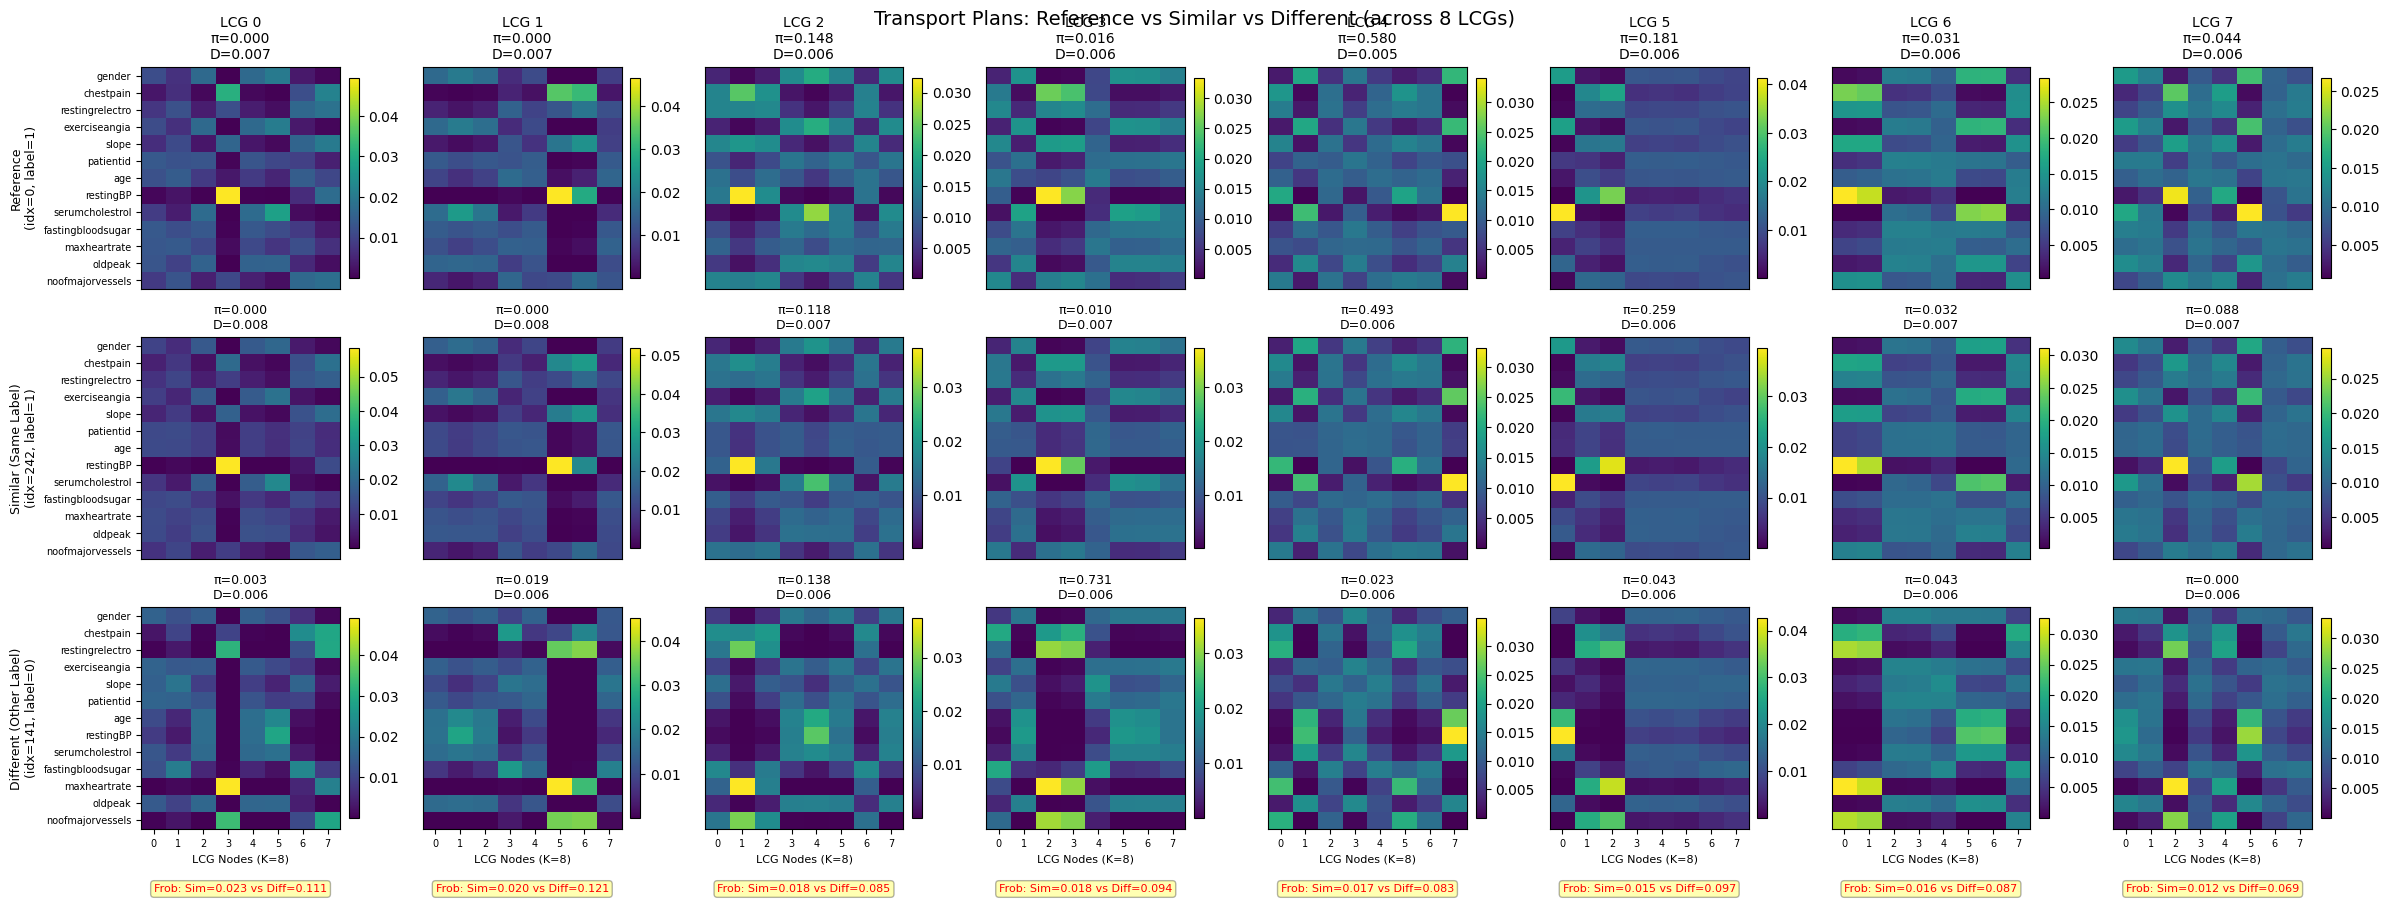

In [109]:
# 시각화
plot_transport_plans_grid(
    plans, coordinates, distances, 
    sample_indices, labels, var_names
)

In [112]:
# Pi (coordinates) 출력
print("=== Pi (Soft Assignment Probabilities) ===")
print("\nReference sample (idx={}, label={}):".format(reference_idx, labels[reference_idx]))
print(coordinates[0])
print(f"Sum: {coordinates[0].sum():.6f}")
print(f"Max: {coordinates[0].max():.4f}, Min: {coordinates[0].min():.4f}")
print(f"Std: {coordinates[0].std():.6f}")

print("\nSimilar sample (idx={}, label={}):".format(similar_idx, labels[similar_idx]))
print(coordinates[1])
print(f"Sum: {coordinates[1].sum():.6f}")
print(f"Max: {coordinates[1].max():.4f}, Min: {coordinates[1].min():.4f}")
print(f"Std: {coordinates[1].std():.6f}")

print("\nDifferent sample (idx={}, label={}):".format(different_idx, labels[different_idx]))
print(coordinates[2])
print(f"Sum: {coordinates[2].sum():.6f}")
print(f"Max: {coordinates[2].max():.4f}, Min: {coordinates[2].min():.4f}")
print(f"Std: {coordinates[2].std():.6f}")

print("\n=== Pi Comparison ===")
print("Reference vs Similar - Frobenius: {:.6f}".format(
    np.linalg.norm(coordinates[0] - coordinates[1])
))
print("Reference vs Different - Frobenius: {:.6f}".format(
    np.linalg.norm(coordinates[0] - coordinates[2])
))

# Raw distances (softmax 전)
print("\n=== Raw FGW Distances (before softmax) ===")
print("Reference:", distances[0])
print("Similar:", distances[1])
print("Different:", distances[2])

print("\n=== Distance Comparison ===")
print("Reference vs Similar - Frobenius: {:.6f}".format(
    np.linalg.norm(distances[0] - distances[1])
))
print("Reference vs Different - Frobenius: {:.6f}".format(
    np.linalg.norm(distances[0] - distances[2])
))

=== Pi (Soft Assignment Probabilities) ===

Reference sample (idx=0, label=1):
[5.1034071e-06 2.0769917e-08 1.4753154e-01 1.6402164e-02 5.8048803e-01
 1.8086147e-01 3.0841822e-02 4.3869860e-02]
Sum: 1.000000
Max: 0.5805, Min: 0.0000
Std: 0.183571

Similar sample (idx=242, label=1):
[3.47615583e-06 5.63084557e-09 1.18216865e-01 1.02012325e-02
 4.93036509e-01 2.58684576e-01 3.16117294e-02 8.82456303e-02]
Sum: 1.000000
Max: 0.4930, Min: 0.0000
Std: 0.161194

Different sample (idx=141, label=0):
[2.6545057e-03 1.9023154e-02 1.3786913e-01 7.3058009e-01 2.3258096e-02
 4.3292183e-02 4.3031711e-02 2.9114902e-04]
Sum: 1.000000
Max: 0.7306, Min: 0.0003
Std: 0.232484

=== Pi Comparison ===
Reference vs Similar - Frobenius: 0.128732
Reference vs Different - Frobenius: 0.917600

=== Raw FGW Distances (before softmax) ===
Reference: [0.00656285 0.00711326 0.00553566 0.00575532 0.00539867 0.00551529
 0.00569217 0.00565694]
Similar: [0.00756308 0.00820562 0.00651965 0.00676465 0.00637684 0.00644134
 0

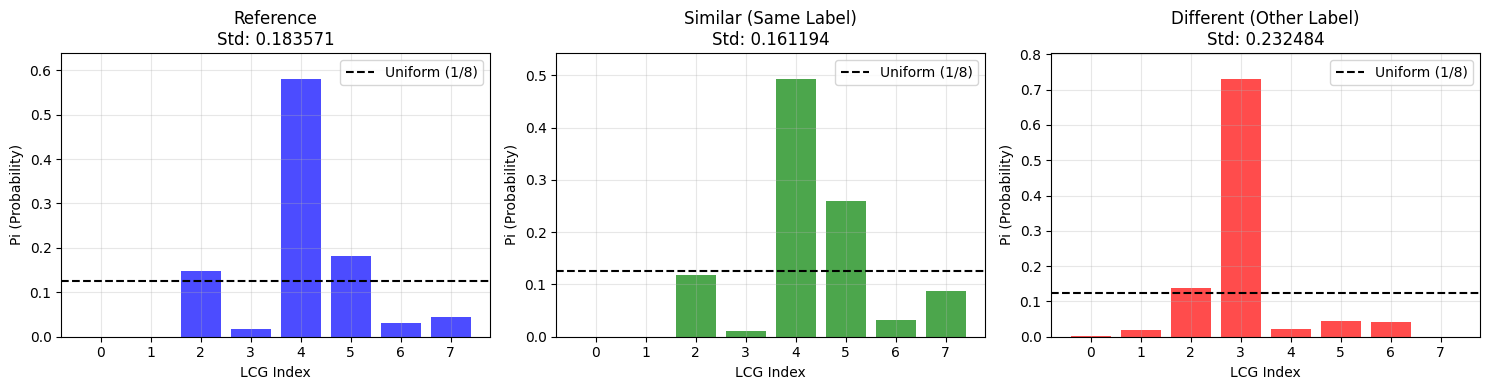

In [113]:
# 시각화: Pi 비교
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [114]:
# 더 자세한 분석: Distance의 variation
print("\n=== Distance Statistics Across Samples ===")
all_dists = np.array([distances[0], distances[1], distances[2]])

print("\nPer-LCG distance variance (across 3 samples):")
for lcg_idx in range(8):
    lcg_dists = all_dists[:, lcg_idx]
    print(f"LCG {lcg_idx}: mean={lcg_dists.mean():.6f}, std={lcg_dists.std():.6f}, range=[{lcg_dists.min():.6f}, {lcg_dists.max():.6f}]")

print("\nPer-Sample distance variance (across 8 LCGs):")
for sample_idx, name in enumerate(sample_names):
    sample_dists = all_dists[sample_idx]
    print(f"{name}: mean={sample_dists.mean():.6f}, std={sample_dists.std():.6f}")


=== Distance Statistics Across Samples ===

Per-LCG distance variance (across 3 samples):
LCG 0: mean=0.006765, std=0.000587, range=[0.006169, 0.007563]
LCG 1: mean=0.007097, std=0.000912, range=[0.005972, 0.008206]
LCG 2: mean=0.005943, std=0.000419, range=[0.005536, 0.006520]
LCG 3: mean=0.006042, std=0.000514, range=[0.005607, 0.006765]
LCG 4: mean=0.005909, std=0.000400, range=[0.005399, 0.006377]
LCG 5: mean=0.005949, std=0.000380, range=[0.005515, 0.006441]
LCG 6: mean=0.006078, std=0.000414, range=[0.005692, 0.006652]
LCG 7: mean=0.006199, std=0.000388, range=[0.005657, 0.006549]

Per-Sample distance variance (across 8 LCGs):
Reference: mean=0.005904, std=0.000566
Similar (Same Label): mean=0.006884, std=0.000610
Different (Other Label): mean=0.005955, std=0.000223


In [115]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

@torch.no_grad()
def collect_all_source_assignments(model, loaders, sources, device):
    """
    모든 source의 모든 샘플에 대해 LCG assignment 수집
    
    Returns:
        assignments: [N_total] - 각 샘플이 어느 LCG node에 할당되었는지
        source_labels: [N_total] - 각 샘플이 어느 source에서 왔는지
    """
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K, D = lcg_feat.shape
    
    all_assignments = []
    all_source_labels = []
    
    for src_idx, src in enumerate(sources):
        loader = loaders[src]
        
        for batch in loader:
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                    for k, v in batch.items()}
            
            # desc/name/value gather
            desc_embeddings, name_embeddings, value_embeddings = [], [], []
            if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
                desc_embeddings.append(batch['cat_desc_embeddings'])
                name_embeddings.append(batch['cat_name_embeddings'])
                value_embeddings.append(batch['cat_value_embeddings'])
            if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
                desc_embeddings.append(batch['num_desc_embeddings'])
                name_embeddings.append(batch['num_name_embeddings'])
                value_embeddings.append(batch['num_prompt_embeddings'])

            name = torch.cat(name_embeddings, dim=1)
            value = torch.cat(value_embeddings, dim=1)
            
            B = value.size(0)
            N = value.size(1)

            # CLS + value
            x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

            # GAT forward
            last_att = None
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, att = model.basis_layers[l](name, norm_x)
                last_att = att
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

            # Source features (CLS 제외)
            src_feat = x_basis[:, 1:, :]  # [B, N, D]
            
            # Affinity (Var-Var, CLS 제외)
            src_str = 1.0 - last_att[:, 0, 1:, 1:]  # [B, N, N]
            
            # Expand for M LCGs
            src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
            src_str_exp = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
            
            lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
            lcg_str_exp = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
            
            # FGW 계산
            dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
            tau = model.graph_quantizer.tau
            M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
            
            a = torch.ones(B*M, N, device=device) / N
            b = torch.ones(B*M, K, device=device) / K
            
            alpha = model.graph_quantizer.alpha
            reg = model.graph_quantizer.reg
            
            result = solve_gromov_batch(
                src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
                a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
            )
            
            # Transport Plan: [B*M, N, K] → [B, M, N, K]
            plan = result.plan.reshape(B, M, N, K)
            
            # 각 샘플의 각 node가 어느 LCG node에 가장 많이 할당되었는지
            # Plan shape: [B, M, N, K]
            # Max over (M, K) → 어느 (LCG, Node)에 가장 많이?
            plan_flat = plan.reshape(B, M*K, N)  # [B, M*K, N]
            
            for b in range(B):
                for n in range(N):
                    # 이 node의 transport plan: [M*K]
                    transport = plan_flat[b, :, n].detach().cpu().numpy()
                    
                    # 가장 높은 할당을 받은 (LCG, Node)
                    best_idx = np.argmax(transport)
                    
                    all_assignments.append(best_idx)
                    all_source_labels.append(src_idx)
    
    return np.array(all_assignments), np.array(all_source_labels)

In [116]:
def plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8):
    """
    Argmax 기반 codebook usage 시각화
    
    Args:
        assignments: [N_total] - LCG*K index (0~63)
        source_labels: [N_total] - source index (0~3)
        sources: list of source names
        M: number of LCGs
        K: number of nodes per LCG
    """
    # 무지개 색상 (8개 LCG)
    colors = plt.cm.rainbow(np.linspace(0, 1, M))
    
    # LCG별, Node별 카운트
    counts = np.zeros((M, K))
    
    for assignment in assignments:
        lcg_idx = assignment // K
        node_idx = assignment % K
        if lcg_idx < M and node_idx < K:
            counts[lcg_idx, node_idx] += 1
    
    # Plot
    fig, ax = plt.subplots(figsize=(18, 6))
    
    x_positions = []
    bar_colors = []
    bar_heights = []
    
    current_x = 0
    for m in range(M):
        for k in range(K):
            x_positions.append(current_x)
            bar_colors.append(colors[m])
            bar_heights.append(counts[m, k])
            current_x += 1
    
    bars = ax.bar(x_positions, bar_heights, color=bar_colors, edgecolor='black', linewidth=0.5)
    
    # X-axis labels
    ax.set_xlabel('LCG Node Index (Color=Graph ID)', fontsize=14)
    ax.set_ylabel('Selection Count', fontsize=14)
    ax.set_title('Best Init: Codebook Usage (Count of Argmax)', fontsize=16)
    
    # X-ticks
    ax.set_xticks(range(0, M*K, 5))
    ax.set_xticklabels(range(0, M*K, 5))
    
    # Grid
    ax.grid(axis='y', alpha=0.3)
    
    # LCG 경계선
    for m in range(1, M):
        ax.axvline(x=m*K - 0.5, color='black', linewidth=2, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\n=== Codebook Usage Statistics (Argmax) ===")
    total_assignments = len(assignments)
    print(f"Total assignments: {total_assignments}")
    
    for m in range(M):
        lcg_count = counts[m].sum()
        print(f"LCG {m}: {int(lcg_count):5d} ({lcg_count/total_assignments*100:.1f}%)")
        
        # 가장 많이 사용된 node
        max_node = np.argmax(counts[m])
        max_count = counts[m, max_node]
        print(f"  → Most used node: {max_node} ({int(max_count)} times)")

Total samples collected: 44510
Assignment range: [0, 63]


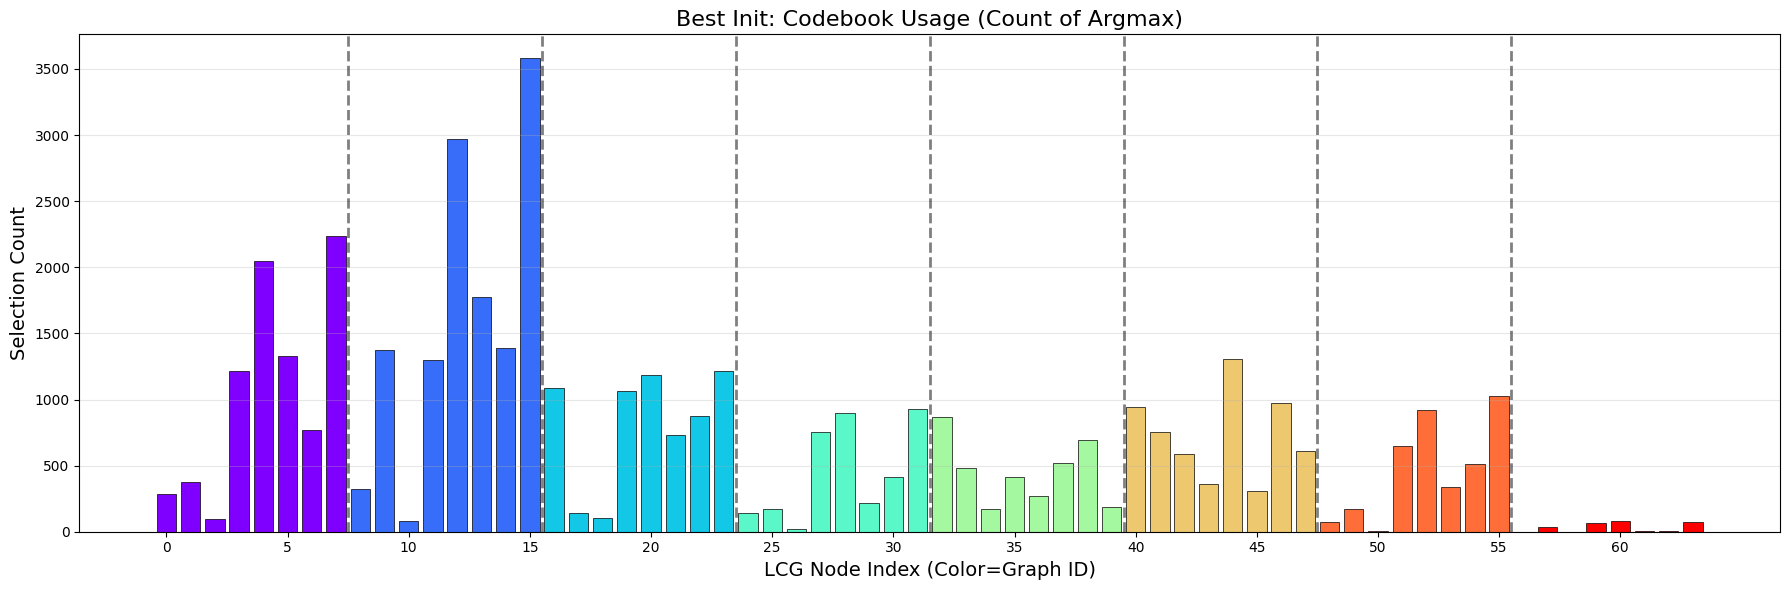


=== Codebook Usage Statistics (Argmax) ===
Total assignments: 44510
LCG 0:  8344 (18.7%)
  → Most used node: 7 (2235 times)
LCG 1: 12795 (28.7%)
  → Most used node: 7 (3583 times)
LCG 2:  6405 (14.4%)
  → Most used node: 7 (1217 times)
LCG 3:  3538 (7.9%)
  → Most used node: 7 (927 times)
LCG 4:  3607 (8.1%)
  → Most used node: 0 (871 times)
LCG 5:  5839 (13.1%)
  → Most used node: 4 (1304 times)
LCG 6:  3715 (8.3%)
  → Most used node: 7 (1027 times)
LCG 7:   267 (0.6%)
  → Most used node: 4 (79 times)


In [117]:
# 실행
print("Collecting assignments from all sources...")
assignments, source_labels = collect_all_source_assignments(
    joint_model_pretrain, loaders, sources, device
)

print(f"Total samples collected: {len(assignments)}")
print(f"Assignment range: [{assignments.min()}, {assignments.max()}]")

# 시각화
plot_codebook_usage_argmax(assignments, source_labels, sources, M=8, K=8)

### Target

In [ ]:
# Target 모델 로드
target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4_entropictest3있음중요함!!/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest3/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251202_182719.pt"
#target_rr_ckpt_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-BASELINE3/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251204_184247.pt"
target_ckpt = torch.load(target_rr_ckpt_path, map_location=device)
target_args = target_ckpt['args']

print("=== Target Checkpoint Info ===")
print(f"Epoch: {target_ckpt.get('epoch', 'unknown')}")
print(f"Val AUC: {target_ckpt.get('val_auc', 'unknown')}")
print(f"Threshold: {target_ckpt.get('threshold', 'unknown')}")
print(f"Keys: {list(target_ckpt.keys())}")

# Target 모델 초기화
target_rr_model = Model(
    target_args,
    target_args.input_dim,
    target_args.hidden_dim,
    target_args.output_dim,
    target_args.dropout_rate,
    target_args.llm_model,
    experiment_id="target_viz",
    mode="Few"
).to(device)

target_sd = target_ckpt['model_state_dict']
missing, unexpected = target_rr_model.load_state_dict(target_sd, strict=False)
print("\nTarget Model Loaded")
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

target_rr_model.eval()

In [ ]:
# Target 데이터 준비 - 간단하게
target_name = target_args.target_data
print(f"\nTarget dataset: {target_name}")

# loaders dict 확인
print(f"Available loaders: {list(loaders.keys())}")

# Target loader 찾기
if target_name in loaders:
    target_loader = loaders[target_name]
    print(f"✓ Found target loader: {target_name}")
else:
    print(f"✗ Target '{target_name}' not in loaders")
    print("Available sources:", list(loaders.keys()))
    # 아무거나 하나 쓰거나 물어보자
    target_loader = list(loaders.values())[0]
    print(f"Using first available loader instead")

In [ ]:
# Target 데이터 로드
from dataset.data_dataloaders import prepare_embedding_dataloaders

print(f"\nLoading target dataset: {target_args.target_data}")

r_t = prepare_embedding_dataloaders(target_args, target_args.target_data)
train_loader_t, val_loader_t, test_loader_t = r_t['loaders']
num_classes_t = r_t['num_classes']

print(f"✓ Target loaded")
print(f"  Num classes: {num_classes_t}")

# Test loader 사용
target_loader = test_loader_t
print(f"  Test samples: {len(test_loader_t.dataset)}")
# Target 샘플 수집
print("\nCollecting target samples...")
target_embeddings, target_affinities, target_labels, target_feature_names = collect_all_samples_from_source(
    target_rr_model, target_loader, target_args.target_data
)

print(f"Total collected: {len(target_embeddings)}")
print(f"Label 0: {(np.array(target_labels) == 0).sum()}")
print(f"Label 1: {(np.array(target_labels) == 1).sum()}")

In [ ]:
# Frobenius distance 계산
print("\nComputing Frobenius distances...")
target_emb_distances, target_aff_distances = compute_frobenius_distances(
    target_embeddings, target_affinities
)

In [ ]:
# Reference, Similar, Different 선택
target_ref_idx = 0

target_sim_idx, target_diff_idx = find_most_similar_and_different_by_label(
    target_ref_idx, target_aff_distances, target_labels
)

print(f"\n=== Target Sample Selection ===")
print(f"Reference: idx={target_ref_idx}, label={target_labels[target_ref_idx]}")
print(f"Similar (same label): idx={target_sim_idx}, label={target_labels[target_sim_idx]}")
print(f"  → Affinity Frob: {target_aff_distances[target_ref_idx, target_sim_idx]:.4f}")
print(f"Different (other label): idx={target_diff_idx}, label={target_labels[target_diff_idx]}")
print(f"  → Affinity Frob: {target_aff_distances[target_ref_idx, target_diff_idx]:.4f}")

In [ ]:
# Transport Plans 계산
print("\nComputing transport plans...")
target_sample_indices = [target_ref_idx, target_sim_idx, target_diff_idx]

target_plans, target_distances, target_coordinates = compute_transport_plans_for_samples(
    target_rr_model, target_sample_indices, target_embeddings, target_affinities
)

print("\n=== Target Pi (Coordinates) ===")
print("Reference:", target_coordinates[0])
print("Similar:", target_coordinates[1])
print("Different:", target_coordinates[2])
# Transport Plans 시각화
plot_transport_plans_grid(
    target_plans, target_coordinates, target_distances,
    target_sample_indices, target_labels, target_feature_names[0]
)

In [ ]:
# Pi 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sample_names = ['Reference', 'Similar (Same Label)', 'Different (Other Label)']
colors = ['blue', 'green', 'red']

for i, (coord, name, color) in enumerate(zip(target_coordinates, sample_names, colors)):
    ax = axes[i]
    ax.bar(range(8), coord, color=color, alpha=0.7)
    ax.set_xlabel('LCG Index')
    ax.set_ylabel('Pi (Probability)')
    ax.set_title(f'{name}\nStd: {coord.std():.6f}')
    ax.set_ylim([0, max(0.2, coord.max() * 1.1)])
    ax.axhline(y=1/8, color='black', linestyle='--', label='Uniform (1/8)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Target Dataset: Pi Distribution', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Codebook Usage (Argmax)
print("\nCollecting codebook usage for target...")
target_assignments, target_source_labels = collect_all_source_assignments(
    target_rr_model, {target_args.target_data: target_loader}, 
    [target_args.target_data], device
)

plot_codebook_usage_argmax(
    target_assignments, target_source_labels, 
    [target_args.target_data], M=8, K=8
)

In [ ]:
@torch.no_grad()
def collect_all_cls_embeddings(model, loaders, device):
    """
    모든 loader의 CLS embeddings 수집
    
    Returns:
        cls_embeddings: [N_total, D] - 모든 CLS embeddings
    """
    all_cls_tokens = []
    model.eval()
    
    for src_name, loader in loaders.items():
        print(f"   - Collecting CLS from: {src_name}")
        for batch in loader:
            batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                    for k, v in batch.items()}
            
            # name/value embeddings
            name_embs, val_embs = [], []
            if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
            if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
            if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
            if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
            
            if not name_embs: continue
            
            name = torch.cat(name_embs, dim=1)
            val = torch.cat(val_embs, dim=1)
            
            # CLS + value
            x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
            
            # GAT forward
            for l in range(model.num_basis_layers):
                norm_x = model.basis_layer_norms[l](x_basis)
                basis_outputs, _ = model.basis_layers[l](name, norm_x)
                x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
            
            # CLS token
            cls_token = x_basis[:, 0, :].cpu().numpy()
            all_cls_tokens.append(cls_token)
    
    return np.concatenate(all_cls_tokens, axis=0)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

def compare_kmeans_clustering(cls_hier, cls_rr, n_clusters=8):
    """
    Hierarchical vs Round Robin의 CLS clustering 비교
    """
    print("="*80)
    print("K-Means Clustering Comparison: Hierarchical vs Round Robin")
    print("="*80)
    
    # K-Means 수행
    print(f"\nPerforming K-Means (n_clusters={n_clusters})...")
    kmeans_hier = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans_rr = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    
    cluster_hier = kmeans_hier.fit_predict(cls_hier)
    cluster_rr = kmeans_rr.fit_predict(cls_rr)
    
    # Metrics 계산
    sil_hier = silhouette_score(cls_hier, cluster_hier)
    sil_rr = silhouette_score(cls_rr, cluster_rr)
    
    db_hier = davies_bouldin_score(cls_hier, cluster_hier)
    db_rr = davies_bouldin_score(cls_rr, cluster_rr)
    
    print(f"\n{'Metric':<30} {'Hierarchical':>15} {'Round Robin':>15} {'Winner':>15}")
    print("-"*80)
    print(f"{'Silhouette Score (↑)':<30} {sil_hier:>15.4f} {sil_rr:>15.4f} {'Hier' if sil_hier > sil_rr else 'RR':>15}")
    print(f"{'Davies-Bouldin (↓)':<30} {db_hier:>15.4f} {db_rr:>15.4f} {'Hier' if db_hier < db_rr else 'RR':>15}")
    
    # Cluster size 분포
    print(f"\n{'Cluster Size Distribution':<30} {'Hierarchical':>15} {'Round Robin':>15}")
    print("-"*80)
    for i in range(n_clusters):
        count_hier = (cluster_hier == i).sum()
        count_rr = (cluster_rr == i).sum()
        print(f"Cluster {i:<23} {count_hier:>15d} {count_rr:>15d}")
    
    # PCA 2D 시각화
    print("\nGenerating visualizations...")
    pca = PCA(n_components=2, random_state=42)
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Hierarchical
    cls_hier_2d = pca.fit_transform(cls_hier)
    ax = axes[0]
    scatter = ax.scatter(cls_hier_2d[:, 0], cls_hier_2d[:, 1], 
                        c=cluster_hier, cmap='tab10', s=20, alpha=0.6, edgecolors='none')
    
    # Centroids
    centroids_hier_2d = pca.transform(kmeans_hier.cluster_centers_)
    ax.scatter(centroids_hier_2d[:, 0], centroids_hier_2d[:, 1],
              c='red', marker='*', s=500, edgecolors='black', linewidths=2, label='Centroids')
    
    ax.set_title(f'Hierarchical: K-Means Clusters\nSilhouette: {sil_hier:.4f} | Davies-Bouldin: {db_hier:.4f}', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster ID')
    
    # Round Robin
    cls_rr_2d = pca.fit_transform(cls_rr)
    ax = axes[1]
    scatter = ax.scatter(cls_rr_2d[:, 0], cls_rr_2d[:, 1],
                        c=cluster_rr, cmap='tab10', s=20, alpha=0.6, edgecolors='none')
    
    # Centroids
    centroids_rr_2d = pca.transform(kmeans_rr.cluster_centers_)
    ax.scatter(centroids_rr_2d[:, 0], centroids_rr_2d[:, 1],
              c='red', marker='*', s=500, edgecolors='black', linewidths=2, label='Centroids')
    
    ax.set_title(f'Round Robin: K-Means Clusters\nSilhouette: {sil_rr:.4f} | Davies-Bouldin: {db_rr:.4f}', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Cluster ID')
    
    plt.tight_layout()
    plt.show()
    
    return cluster_hier, cluster_rr

In [ ]:
# Hierarchical 모델 CLS 수집
print("="*80)
print("Loading Hierarchical Model...")
print("="*80)

hier_ckpt_target_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4_entropictest3있음중요함!!/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251202_170233.pt"
hier_ckpt_target = torch.load(hier_ckpt_target_path, map_location=device)
hier_model_target = Model(
    hier_ckpt_target['args'],
    hier_ckpt_target['args'].input_dim,
    hier_ckpt_target['args'].hidden_dim,
    hier_ckpt_target['args'].output_dim,
    hier_ckpt_target['args'].dropout_rate,
    hier_ckpt_target['args'].llm_model,
    experiment_id="hier_kmeans",
    mode="Few"
).to(device)
hier_model_target.load_state_dict(hier_ckpt_target['model_state_dict'], strict=False)
hier_model_target.eval()

# Sources + Target
from dataset.data_dataloaders import prepare_embedding_dataloaders
r_t_hier = prepare_embedding_dataloaders(hier_ckpt_target['args'], hier_ckpt_target['args'].target_data)
target_loader_hier = {hier_ckpt_target['args'].target_data: r_t_hier['loaders'][2]}

all_loaders_hier = {**loaders, **target_loader_hier}

print("\nCollecting CLS from Hierarchical model (Sources + Target)...")
cls_hier = collect_all_cls_embeddings(hier_model_target, all_loaders_hier, device)
print(f"✓ Hierarchical CLS collected: {cls_hier.shape}")

In [ ]:
# Round Robin 모델 CLS 수집
print("\n" + "="*80)
print("Loading Round Robin Model...")
print("="*80)

#rr_ckpt_target_path = "/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4_entropictest3있음중요함!!/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-entropictest3/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251202_182719.pt"
rr_ckpt_target_path ="/storage/personal/eungyeop/experiments/checkpoints/gpt2_mean/Heart_disease_statlog+Cardiovascular_Disease_Dataset+heart_target_3+heart_target_4/Few/ngraphs-8_nnodes-8_gdim-768_nbasis-2_basis-ind_attn-gat_v1_fgw_alpha-1_vq_beta-0.3_kl_gamma-2.0_target_data-heart_description-BASELINE3/42/Embed:carte_Edge:mlp_A:gat_v1_S:42_20251204_184247.pt"
rr_ckpt_target = torch.load(rr_ckpt_target_path, map_location=device)
rr_model_target = Model(
    rr_ckpt_target['args'],
    rr_ckpt_target['args'].input_dim,
    rr_ckpt_target['args'].hidden_dim,
    rr_ckpt_target['args'].output_dim,
    rr_ckpt_target['args'].dropout_rate,
    rr_ckpt_target['args'].llm_model,
    experiment_id="rr_kmeans",
    mode="Few"
).to(device)
rr_model_target.load_state_dict(rr_ckpt_target['model_state_dict'], strict=False)
rr_model_target.eval()

# Sources + Target
r_t_rr = prepare_embedding_dataloaders(rr_ckpt_target['args'], rr_ckpt_target['args'].target_data)
target_loader_rr = {rr_ckpt_target['args'].target_data: r_t_rr['loaders'][2]}

all_loaders_rr = {**loaders, **target_loader_rr}

print("\nCollecting CLS from Round Robin model (Sources + Target)...")
cls_rr = collect_all_cls_embeddings(rr_model_target, all_loaders_rr, device)
print(f"✓ Round Robin CLS collected: {cls_rr.shape}")

In [ ]:
# K-Means 비교
cluster_hier, cluster_rr = compare_kmeans_clustering(cls_hier, cls_rr, n_clusters=8)

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

def visualize_lcg_with_all_data_sidebyside_unified(hier_model, rr_model, loaders, sources, device):
    """
    Hierarchical vs Round Robin 나란히 비교 (통일된 PCA)
    """
    from dataset.data_dataloaders import prepare_embedding_dataloaders
    
    # 1. Hierarchical 데이터 수집
    print("Collecting Hierarchical data...")
    lcg_hier, _ = hier_model.latent_graph()
    M, K, D = lcg_hier.shape
    lcg_hier_nodes = lcg_hier.reshape(M*K, D).detach().cpu().numpy()
    lcg_hier_labels = np.repeat(range(M), K)
    
    cls_hier_src, src_hier_labels = collect_cls_by_source(hier_model, loaders, sources, device)
    
    r_t_hier = prepare_embedding_dataloaders(hier_model.args, hier_model.args.target_data)
    target_loader_hier = {hier_model.args.target_data: r_t_hier['loaders'][2]}
    cls_hier_tgt, _ = collect_cls_by_source(hier_model, target_loader_hier, [hier_model.args.target_data], device)
    
    # 2. Round Robin 데이터 수집
    print("Collecting Round Robin data...")
    lcg_rr, _ = rr_model.latent_graph()
    lcg_rr_nodes = lcg_rr.reshape(M*K, D).detach().cpu().numpy()
    lcg_rr_labels = np.repeat(range(M), K)
    
    cls_rr_src, src_rr_labels = collect_cls_by_source(rr_model, loaders, sources, device)
    
    r_t_rr = prepare_embedding_dataloaders(rr_model.args, rr_model.args.target_data)
    target_loader_rr = {rr_model.args.target_data: r_t_rr['loaders'][2]}
    cls_rr_tgt, _ = collect_cls_by_source(rr_model, target_loader_rr, [rr_model.args.target_data], device)
    
    # 3. 통일된 PCA (모든 데이터 합쳐서)
    print("Performing unified PCA...")
    pca = PCA(n_components=2, random_state=42)
    
    # Hierarchical: 모든 데이터 합치기
    all_hier_data = np.vstack([cls_hier_src, cls_hier_tgt, lcg_hier_nodes])
    all_hier_2d = pca.fit_transform(all_hier_data)
    
    cls_hier_src_2d = all_hier_2d[:len(cls_hier_src)]
    cls_hier_tgt_2d = all_hier_2d[len(cls_hier_src):len(cls_hier_src)+len(cls_hier_tgt)]
    lcg_hier_2d = all_hier_2d[len(cls_hier_src)+len(cls_hier_tgt):]
    
    # Round Robin: 같은 PCA transform 적용
    all_rr_data = np.vstack([cls_rr_src, cls_rr_tgt, lcg_rr_nodes])
    all_rr_2d = pca.transform(all_rr_data)  # fit 말고 transform!
    
    cls_rr_src_2d = all_rr_2d[:len(cls_rr_src)]
    cls_rr_tgt_2d = all_rr_2d[len(cls_rr_src):len(cls_rr_src)+len(cls_rr_tgt)]
    lcg_rr_2d = all_rr_2d[len(cls_rr_src)+len(cls_rr_tgt):]
    
    # 4. 시각화
    fig, axes = plt.subplots(1, 2, figsize=(24, 10))
    
    # Source 색상 (중간 진하기)
    source_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    source_names_short = ['Heart_stat', 'Cardio_Dise', 'heart_t3', 'heart_t4']
    
    # Target 색상
    target_color = '#9D4EDD'
    
    # LCG 색상
    lcg_colors = plt.cm.rainbow(np.linspace(0, 1, M))
    
    # --- Hierarchical ---
    ax = axes[0]
    
    # Sources (중간 진하기)
    for src_idx in range(len(sources)):
        mask = (src_hier_labels == src_idx)
        ax.scatter(cls_hier_src_2d[mask, 0], cls_hier_src_2d[mask, 1],
                  c=source_colors[src_idx], s=25, alpha=0.6,
                  label=f'Src: {source_names_short[src_idx]}', edgecolors='none')
    
    # Target
    ax.scatter(cls_hier_tgt_2d[:, 0], cls_hier_tgt_2d[:, 1],
              c=target_color, s=35, alpha=0.7, marker='^',
              label='Target: heart', edgecolors='black', linewidths=0.5)
    
    # LCG nodes
    for m in range(M):
        mask = (lcg_hier_labels == m)
        nodes_m = lcg_hier_2d[mask]
        
        ax.scatter(nodes_m[:, 0], nodes_m[:, 1],
                  c=[lcg_colors[m]], s=120, marker='D',
                  edgecolors='black', linewidths=1.5,
                  label=f'LCG {m}', alpha=0.95, zorder=10)
    
    ax.set_title('Hierarchical: LCG + Sources + Target',
                fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=14)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center',
             fontsize=10, ncol=7, frameon=True, shadow=True)
    
    # --- Round Robin ---
    ax = axes[1]
    
    # Sources (중간 진하기)
    for src_idx in range(len(sources)):
        mask = (src_rr_labels == src_idx)
        ax.scatter(cls_rr_src_2d[mask, 0], cls_rr_src_2d[mask, 1],
                  c=source_colors[src_idx], s=25, alpha=0.6,
                  label=f'Src: {source_names_short[src_idx]}', edgecolors='none')
    
    # Target
    ax.scatter(cls_rr_tgt_2d[:, 0], cls_rr_tgt_2d[:, 1],
              c=target_color, s=35, alpha=0.7, marker='^',
              label='Target: heart', edgecolors='black', linewidths=0.5)
    
    # LCG nodes
    for m in range(M):
        mask = (lcg_rr_labels == m)
        nodes_m = lcg_rr_2d[mask]
        
        ax.scatter(nodes_m[:, 0], nodes_m[:, 1],
                  c=[lcg_colors[m]], s=120, marker='D',
                  edgecolors='black', linewidths=1.5,
                  label=f'LCG {m}', alpha=0.95, zorder=10)
    
    ax.set_title('Round Robin: LCG + Sources + Target',
                fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=14)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(0.5, -0.12), loc='upper center',
             fontsize=10, ncol=7, frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.13)
    plt.show()
    
    # 통계
    print(f"\n{'='*80}")
    print("Data Statistics")
    print(f"{'='*80}")
    print(f"Sources:")
    for src_idx, src_name in enumerate(sources):
        count = (src_hier_labels == src_idx).sum()
        print(f"  {src_name}: {count} samples")
    print(f"\nTarget (Hier): {len(cls_hier_tgt)} samples")
    print(f"Target (RR): {len(cls_rr_tgt)} samples")
    print(f"\nLCG: M={M}, K={K}, Total nodes={M*K}")


def collect_cls_by_source(model, loaders, sources, device):
    """CLS 수집"""
    all_cls = []
    source_labels = []
    
    model.eval()
    with torch.no_grad():
        for src_idx, src_name in enumerate(sources):
            loader = loaders[src_name]
            
            for batch in loader:
                batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                        for k, v in batch.items()}
                
                name_embs, val_embs = [], []
                if 'cat_name_embeddings' in batch: name_embs.append(batch['cat_name_embeddings'])
                if 'num_name_embeddings' in batch: name_embs.append(batch['num_name_embeddings'])
                if 'cat_value_embeddings' in batch: val_embs.append(batch['cat_value_embeddings'])
                if 'num_prompt_embeddings' in batch: val_embs.append(batch['num_prompt_embeddings'])
                
                if not name_embs: continue
                
                name = torch.cat(name_embs, dim=1)
                val = torch.cat(val_embs, dim=1)
                
                x_basis = torch.cat([model.basis_cls.expand(val.size(0), 1, model.input_dim), val], dim=1)
                
                for l in range(model.num_basis_layers):
                    norm_x = model.basis_layer_norms[l](x_basis)
                    basis_outputs, _ = model.basis_layers[l](name, norm_x)
                    x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)
                
                cls_token = x_basis[:, 0, :].cpu().numpy()
                all_cls.append(cls_token)
                source_labels.extend([src_idx] * cls_token.shape[0])
    
    return np.vstack(all_cls), np.array(source_labels)

In [ ]:
# 실행
visualize_lcg_with_all_data_sidebyside_unified(hier_model_target, rr_model_target, loaders, sources, device)

In [ ]:
def find_most_representative_samples_for_each_lcg(model, loader, source_name, device):
    """
    각 LCG를 가장 잘 대표하는 샘플 찾기 (해당 LCG에만 가깝고 다른 LCG와는 먼)
    """
    # [이전 코드와 동일하게 데이터 수집]
    lcg_feat, lcg_struct = model.latent_graph()
    M, K, D = lcg_feat.shape
    
    all_distances_to_lcgs = []
    all_plans = []
    all_embeddings = []
    all_affinities = []
    
    # ... [이전 수집 코드와 동일] ...
    for batch in loader:
        batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) 
                for k, v in batch.items()}
        
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'])
            name_embeddings.append(batch['cat_name_embeddings'])
            value_embeddings.append(batch['cat_value_embeddings'])
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'])
            name_embeddings.append(batch['num_name_embeddings'])
            value_embeddings.append(batch['num_prompt_embeddings'])

        name = torch.cat(name_embeddings, dim=1)
        value = torch.cat(value_embeddings, dim=1)
        
        B = value.size(0)
        N = value.size(1)

        x_basis = torch.cat([model.basis_cls.expand(B, 1, model.input_dim), value], dim=1)

        last_att = None
        for l in range(model.num_basis_layers):
            norm_x = model.basis_layer_norms[l](x_basis)
            basis_outputs, att = model.basis_layers[l](name, norm_x)
            last_att = att
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), model.input_dim)

        src_feat = x_basis[:, 1:, :]
        src_str = 1.0 - last_att[:, 0, 1:, 1:]
        
        src_feat_exp = src_feat.unsqueeze(1).expand(B, M, N, D).reshape(B*M, N, D)
        src_str_exp = src_str.unsqueeze(1).expand(B, M, N, N).reshape(B*M, N, N)
        
        lcg_feat_exp = lcg_feat.unsqueeze(0).expand(B, M, K, D).reshape(B*M, K, D)
        lcg_str_exp = lcg_struct.unsqueeze(0).expand(B, M, K, K).reshape(B*M, K, K)
        
        dist_sq = torch.cdist(src_feat_exp, lcg_feat_exp, p=2) ** 2
        tau = model.graph_quantizer.tau
        M_cost = 1.0 - torch.exp(-dist_sq / (D * tau))
        
        a = torch.ones(B*M, N, device=device) / N
        b = torch.ones(B*M, K, device=device) / K
        
        alpha = model.graph_quantizer.alpha
        reg = model.graph_quantizer.reg
        
        result = solve_gromov_batch(
            src_str_exp, lcg_str_exp, M=M_cost, alpha=alpha, reg=reg,
            a=a, b=b, max_iter=10, tol=1e-3, grad='envelope'
        )
        
        distances = result.value.reshape(B, M).detach().cpu().numpy()
        plans = result.plan.reshape(B, M, N, K).detach().cpu().numpy()
        
        all_distances_to_lcgs.append(distances)
        
        for b in range(B):
            all_plans.append(plans[b])
            all_embeddings.append(src_feat[b].detach().cpu().numpy())
            all_affinities.append(src_str[b].detach().cpu().numpy())
    
    all_distances_to_lcgs = np.vstack(all_distances_to_lcgs)
    
    # ===== 수정된 부분 =====
    best_sample_indices = []
    best_scores = []
    
    for m in range(M):
        # LCG m과의 거리
        dist_to_m = all_distances_to_lcgs[:, m]
        
        # 다른 LCG들과의 평균 거리
        other_lcgs = [i for i in range(M) if i != m]
        dist_to_others = all_distances_to_lcgs[:, other_lcgs].mean(axis=1)
        
        # Relative score: m에 가깝고 others와 먼 정도
        # negative가 클수록 = m에 특화
        relative_score = dist_to_m - dist_to_others
        
        best_idx = np.argmin(relative_score)
        
        best_sample_indices.append(best_idx)
        best_scores.append(relative_score[best_idx])
    
    return (np.array(best_sample_indices), 
            np.array(best_scores),
            all_plans, 
            all_embeddings, 
            all_affinities)

In [ ]:
def plot_transport_plans_for_lcg_closest(plans_list, sample_indices, distances, source_name, M=8):
    """
    각 LCG에 가장 가까운 샘플의 Transport Plan 시각화 (8x8)
    
    Args:
        plans_list: list of [M, N, K] - 전체 샘플의 plans
        sample_indices: [M] - 각 LCG에 가장 가까운 샘플 index
        distances: [M] - 각 LCG까지의 거리
        source_name: source 이름
        M: number of LCGs
    """
    fig, axes = plt.subplots(M, M, figsize=(24, 24))
    
    for lcg_idx in range(M):
        # 이 LCG에 가장 가까운 샘플
        sample_idx = sample_indices[lcg_idx]
        sample_plans = plans_list[sample_idx]  # [M, N, K]
        
        for target_lcg in range(M):
            ax = axes[lcg_idx, target_lcg]
            
            # 이 샘플의 target_lcg로의 plan
            plan = sample_plans[target_lcg]  # [N, K]
            
            # Heatmap
            im = ax.imshow(plan, cmap='viridis', aspect='auto')
            
            # Title (첫 행만)
            if lcg_idx == 0:
                ax.set_title(f'To LCG {target_lcg}', fontsize=10)
            
            # Y-label (첫 열만)
            if target_lcg == 0:
                ax.set_ylabel(f'Sample closest to LCG {lcg_idx}\n(idx={sample_idx}, D={distances[lcg_idx]:.4f})',
                             fontsize=9)
            
            # X-axis
            if lcg_idx == M - 1:
                ax.set_xlabel(f'LCG {target_lcg} Nodes', fontsize=8)
            
            # Ticks
            if target_lcg == 0:
                ax.set_yticks(range(0, plan.shape[0], max(1, plan.shape[0]//5)))
            else:
                ax.set_yticks([])
            
            if lcg_idx == M - 1:
                ax.set_xticks(range(0, plan.shape[1], max(1, plan.shape[1]//4)))
            else:
                ax.set_xticks([])
            
            # Colorbar
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    plt.suptitle(f'Transport Plans: {source_name}\n(Each row = Sample closest to corresponding LCG)',
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

In [ ]:
# 재실행
print("="*80)
print("Finding most representative samples for each LCG...")
print("="*80)

source_name = 'heart_target_4'
source_loader = loaders[source_name]

print(f"\nAnalyzing source: {source_name}")

best_indices, best_scores, all_plans, all_embs, all_affs = find_most_representative_samples_for_each_lcg(
    rr_model_target, source_loader, source_name, device
)

print(f"\n✓ Found representative samples for each LCG:")
for m in range(8):
    print(f"  LCG {m}: Sample {best_indices[m]:4d} (Relative score: {best_scores[m]:.6f})")

In [ ]:
# 시각화
plot_transport_plans_for_lcg_closest(
    all_plans, best_indices, best_scores, source_name, M=8
)

In [ ]:
# 재실행
print("="*80)
print("Finding most representative samples for each LCG...")
print("="*80)

source_name = 'Cardiovascular_Disease_Dataset'
source_loader = loaders[source_name]

print(f"\nAnalyzing source: {source_name}")

best_indices, best_scores, all_plans, all_embs, all_affs = find_most_representative_samples_for_each_lcg(
    hier_model_target, source_loader, source_name, device
)

print(f"\n✓ Found representative samples for each LCG:")
for m in range(8):
    print(f"  LCG {m}: Sample {best_indices[m]:4d} (Relative score: {best_scores[m]:.6f})")
# 시각화
plot_transport_plans_for_lcg_closest(
    all_plans, best_indices, best_scores, source_name, M=8
)

In [ ]:
# Target 데이터 준비
from dataset.data_dataloaders import prepare_embedding_dataloaders

print("="*80)
print("Preparing Target dataset...")
print("="*80)

# Target loader 준비
target_name = rr_model_target.args.target_data  # 'heart'
r_t = prepare_embedding_dataloaders(rr_model_target.args, target_name)
target_test_loader = r_t['loaders'][2]  # Test set

print(f"Target: {target_name}")
print(f"Test samples: {len(target_test_loader.dataset)}")

# Target에 대해 실행
print("\n" + "="*80)
print("Finding most representative samples for each LCG (Target)...")
print("="*80)

best_indices_tgt, best_scores_tgt, all_plans_tgt, all_embs_tgt, all_affs_tgt = find_most_representative_samples_for_each_lcg(
    rr_model_target, target_test_loader, target_name, device
)

print(f"\n✓ Found representative samples for each LCG (Target):")
for m in range(8):
    print(f"  LCG {m}: Sample {best_indices_tgt[m]:4d} (Relative score: {best_scores_tgt[m]:.6f})")

In [ ]:
# 시각화
plot_transport_plans_for_lcg_closest(
    all_plans_tgt, best_indices_tgt, best_scores_tgt, f"Target: {target_name}", M=8
)

### Hierachical Assignment 

In [ ]:
# Target 데이터 준비
from dataset.data_dataloaders import prepare_embedding_dataloaders

print("="*80)
print("Preparing Target dataset...")
print("="*80)

# Target loader 준비
target_name = hier_model_target.args.target_data  # 'heart'
r_t = prepare_embedding_dataloaders(hier_model_target.args, target_name)
target_test_loader = r_t['loaders'][2]  # Test set

print(f"Target: {target_name}")
print(f"Test samples: {len(target_test_loader.dataset)}")

# Target에 대해 실행
print("\n" + "="*80)
print("Finding most representative samples for each LCG (Target)...")
print("="*80)

best_indices_tgt, best_scores_tgt, all_plans_tgt, all_embs_tgt, all_affs_tgt = find_most_representative_samples_for_each_lcg(
    hier_model_target, target_test_loader, target_name, device
)

print(f"\n✓ Found representative samples for each LCG (Target):")
for m in range(8):
    print(f"  LCG {m}: Sample {best_indices_tgt[m]:4d} (Relative score: {best_scores_tgt[m]:.6f})")

In [ ]:
# 시각화
plot_transport_plans_for_lcg_closest(
    all_plans_tgt, best_indices_tgt, best_scores_tgt, f"Target: {target_name}", M=8
)

## round robin

In [ ]:
def plot_attentions_for_lcg_representatives(affinities_list, sample_indices, scores, source_name, feature_names, M=8):
    """
    각 LCG 대표 샘플의 Attention 시각화 (8개)
    Attention = 1 - Affinity (높을수록 관련 있음)
    """
    fig, axes = plt.subplots(2, 4, figsize=(24, 12))
    axes = axes.flatten()
    
    for m in range(M):
        ax = axes[m]
        
        # 이 LCG의 대표 샘플
        sample_idx = sample_indices[m]
        affinity = affinities_list[sample_idx]  # [N, N]
        
        # Attention = 1 - Affinity
        attention = 1.0 - affinity
        
        vmin = attention.min()
        vmax = attention.max()
        
        # Heatmap (viridis colormap)
        im = ax.imshow(attention, cmap='viridis', aspect='auto', vmin=vmin, vmax=vmax)
        
        ax.set_title(f'LCG {m}: Sample {sample_idx}', 
                    fontsize=12, fontweight='bold')
        
        # Axis labels
        N = attention.shape[0]
        if feature_names is not None and len(feature_names) == N:
            ax.set_xticks(range(N))
            ax.set_yticks(range(N))
            ax.set_xticklabels(feature_names, rotation=90, fontsize=8)
            ax.set_yticklabels(feature_names, fontsize=8)
        else:
            ax.set_xlabel('Variables', fontsize=10)
            ax.set_ylabel('Variables', fontsize=10)
            # Ticks
            tick_step = max(1, N // 10)
            ax.set_xticks(range(0, N, tick_step))
            ax.set_yticks(range(0, N, tick_step))
        
        # 값 표시 (작은 행렬일 때만)
        if N <= 15:
            for i in range(N):
                for j in range(N):
                    text_color = "white" if attention[i, j] > (vmin + vmax) / 2 else "black"
                    ax.text(j, i, f"{attention[i, j]:.2f}",
                           ha="center", va="center",
                           fontsize=6, color=text_color)
        
        # Colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Attention', fontsize=9)
    
    plt.suptitle(f'Attention Matrices: {source_name}\n(Each subplot = Attention of representative sample for corresponding LCG)',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Target 데이터 준비
from dataset.data_dataloaders import prepare_embedding_dataloaders

print("="*80)
print("Preparing Target dataset...")
print("="*80)

target_name = rr_model_target.args.target_data  # 'heart'
r_t = prepare_embedding_dataloaders(rr_model_target.args, target_name)
target_test_loader = r_t['loaders'][2]

print(f"Target: {target_name}")
print(f"Test samples: {len(target_test_loader.dataset)}")

In [ ]:
# Round Robin Target - 대표 샘플 찾기
print("\n" + "="*80)
print("Finding representative samples (Round Robin Target)...")
print("="*80)

best_indices_rr_tgt, best_scores_rr_tgt, all_plans_rr_tgt, all_embs_rr_tgt, all_affs_rr_tgt = find_most_representative_samples_for_each_lcg(
    rr_model_target, target_test_loader, target_name, device
)

print(f"\n✓ Found representative samples (RR Target):")
for m in range(8):
    print(f"  LCG {m}: Sample {best_indices_rr_tgt[m]:4d} (Score: {best_scores_rr_tgt[m]:.6f})")

In [ ]:
# Round Robin Target - Attention 시각화
print("\n" + "="*80)
print("Visualizing Attentions (Round Robin Target)...")
print("="*80)

plot_attentions_for_lcg_representatives(
    all_affs_rr_tgt, best_indices_rr_tgt, best_scores_rr_tgt, 
    f"Round Robin Target: {target_name}", None, M=8
)

### Latent Composite graph Affinity

In [ ]:
@torch.no_grad()
def visualize_lcg_structures(model, model_name):
    """
    LCG의 학습된 Structure (Affinity) 시각화
    
    Args:
        model: 학습된 모델
        model_name: 'Round Robin' or 'Hierarchical'
    """
    # LCG 가져오기
    lcg_feat, lcg_struct = model.latent_graph()  # [M, K, D], [M, K, K]
    M, K = lcg_struct.shape[0], lcg_struct.shape[1]
    
    lcg_struct_np = lcg_struct.detach().cpu().numpy()
    
    # 시각화 (2x4 grid)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    for m in range(M):
        ax = axes[m]
        
        struct = lcg_struct_np[m]  # [K, K]
        
        # Heatmap
        im = ax.imshow(struct, cmap='viridis', aspect='auto', vmin=0, vmax=1)
        
        ax.set_title(f'LCG {m} Structure', fontsize=12, fontweight='bold')
        ax.set_xlabel('Nodes', fontsize=10)
        ax.set_ylabel('Nodes', fontsize=10)
        
        # Ticks
        ax.set_xticks(range(K))
        ax.set_yticks(range(K))
        
        # 값 표시 (K가 작을 때)
        if K <= 10:
            for i in range(K):
                for j in range(K):
                    text_color = 'white' if struct[i, j] > 0.5 else 'black'
                    ax.text(j, i, f'{struct[i, j]:.2f}',
                           ha='center', va='center',
                           fontsize=8, color=text_color)
        
        # Colorbar
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Affinity', fontsize=9)
        
        # Statistics
        entropy = -(struct * np.log(struct + 1e-10)).sum() / (K * K)
        mean_affinity = struct.mean()
        std_affinity = struct.std()
        
        # Text box
        textstr = f'Entropy: {entropy:.3f}\nMean: {mean_affinity:.3f}\nStd: {std_affinity:.3f}'
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.98, 0.02, textstr, transform=ax.transAxes, fontsize=8,
               verticalalignment='bottom', horizontalalignment='right', bbox=props)
    
    plt.suptitle(f'{model_name}: Learned LCG Structures (Affinity Matrices)',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 통합 통계
    print(f"\n{'='*60}")
    print(f"{model_name} - LCG Structure Statistics")
    print(f"{'='*60}")
    
    for m in range(M):
        struct = lcg_struct_np[m]
        entropy = -(struct * np.log(struct + 1e-10)).sum() / (K * K)
        mean_aff = struct.mean()
        std_aff = struct.std()
        
        # Diagonal vs off-diagonal
        diag = np.diag(struct).mean()
        off_diag = (struct.sum() - np.diag(struct).sum()) / (K * K - K)
        
        print(f"\nLCG {m}:")
        print(f"  Entropy:      {entropy:.4f}")
        print(f"  Mean affinity: {mean_aff:.4f}")
        print(f"  Std affinity:  {std_aff:.4f}")
        print(f"  Diagonal:      {diag:.4f}")
        print(f"  Off-diagonal:  {off_diag:.4f}")

In [ ]:
# Round Robin Target
print("="*80)
print("Visualizing LCG Structures (Round Robin Target)...")
print("="*80)

visualize_lcg_structures(rr_model_target, "Round Robin Target")

In [ ]:
# Hierarchical Target
print("\n" + "="*80)
print("Visualizing LCG Structures (Hierarchical Target)...")
print("="*80)

visualize_lcg_structures(hier_model_target, "Hierarchical Target")